<div style="display:none">
$$
\newcommand{\rvar}[1]{\mathrm{#1}}
\newcommand{\rvec}[1]{\mathbf{#1}}
\newcommand{\vec}[1]{\pmb{#1}}
\newcommand{\tens}[1]{\pmb{\mathsf{#1}}}
\newcommand{\tensel}[1]{\mathsf{#1}}
\newcommand{\st}[1]{\mathcal{#1}}
\newcommand{\diag}[1]{\mathrm{diag}(\vec{#1})}
$$
</div>

In [7]:
# some initialization stuff
%run ../init.py
%matplotlib inline

from rf.agent import Bandit, Stationary, Decreasing

<IPython.core.display.Latex object>

# Reinforcement learning

+ Agent-oriented learning-learning by interacting with an environment to achieve a goal
    - Some researchers believe that RL is more realistic and ambitious than other kinds of machine learning
+ Learning by trial and error, with only delayed evaluative feedback (reward)
    - Kind of machine learning corresponding to a natural learning of a toddler
    - Learning that can tell for itself when it is right or wrong (minor penalty for the false action)
    

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/04_RL/images/dog.jpg" width="40%"/>
</center>
<p style="text-align:right">https://sandraschoppers.wordpress.com</p>

## General idea

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/04_RL/images/rl-schema.jpg" width="40%"/>
</center>

- At each step $t$ the agent:
    - Selects and executes an action $a_t$
    - Sensors environment observations $o_t$
    - Receives reward $r_t$
- The environment:
    - Changes its state according to the action $a_t$
    - Emits the observation $o_t$
    - Generates a scalar reward $r_t$

## Pros and cons

- Use when:
    - the environment is hard or even impossible to model
    - the model of the environment is too complex to be solved exactly and an _acceptable approximate_ solution should be found 

- Issues:
  - In most cases, communication of "desired"/"unwanted" behavior to an agent can only be done using rewards
     + Actions might have long-term consequences 
     + Sometimes it is better to sacrifice immediate reward to gain more long-term rewards
     + Reward is delayed till the end of a sequence of actions  
  - Active exploration of the environment might take considerable time
  - (Partially) observable states provide incomplete information
  - Learn to use same sensors/effectors for multiple tasks with

## Example: Backgammon [Tesauro et al., 1995]

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/04_RL/images/backgammon.png" width="30%"/>
</center>
<p style="text-align:right">wikipedia.org</p>

+ Positions: 28, Avg. game length: 55, Branching: 250
+ Immediate reward
    - $+100$ if win
    - $-100$ if lose
    - $0$ for all other states
+ Trained by playing 1.5 million games against itself
+ Gained a level approximately equal to best human player

## Example: GO [Silver et al., 2016]

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/04_RL/images/go.jpg" width="30%"/>
</center>
<p style="text-align:right">wikipedia.org</p>

+ Positions: 361, Avg. game length: 150, Branching: 250
+ Deep Learning (Google's Deep Mind company)
    - Applied first to Atari games
    - Combine neural networks with search techniques (Monte Carlo-Tree Search)
+ GO is considered notoriously hard (EXPTIME-complete)

## Other examples

- Trained acrobatics autopilot for a toy helicopter  (Ng et al., 2006)
- Widely used in the placement and selection of advertisements and pages on the Web (e.g., A-B tests)
- Used to make strategic decisions in Jeopardy! (IBM's Watson 2011)
- Achieved human-level performance on Atari games from *pixel-level visual input*, in conjunction with deep learning (Google Deepmind 2015)

In all these cases, performance was better than could be obtained by any other method, and was obtained without human instruction

## Learning agent and environment

- *Given*: observations of the environment and (possibly) knowledge about it
- *Goal*: find a policy $\pi^*(s)$ allowing for the selection of actions that maximize cumulative rewards 


- Learning problem:
  + *Task*: learning the optimal decision making policy $\pi^*(s)$ for an agent
  + *Experience*: $D=\{\langle s, a, s',r \rangle\}$ 
  + *Performance measure*: maximize the reward

# Off-policy Methods

## Single state problems
+ A learner uses training information by *evaluating* its actions rather than by using instructions indicating *correct* actions
+ Feedback can be 
  - Evaluative - depends completely on a taken action
  - Instructive - is independent of actions (supervised learning)
  - The two types of feedback can be combined
+ A reward received by an agent can be
  - *immediate* - after each action, or 
  - *deferred* - after a number of actions (sequence of states)

## *k*-armed Bandit Problem

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/04_RL/images/octopus.png" width="40%"/>
</center>

**Problem description**:
+ *Given* a slot machine with $k$ levers such that each lever has a different winning probability
+ *Find* the best levers that allow for the maximization of your winnings 


*k-armed Bandit* as a reinforcement learning problem:
- State: there is only one initial state (the slot machine has no history) 
- Actions: a choice between *k* different levers
- Rewards: a number from a stationary probability distribution that depends only on the selected action (evaluative immediate feedback)  
- Learn: actions that maximize the reward

## Value of an action 

- Let us denote an action taken at a time $t$ as $A_t$ and the reward as $R_t$
  + For instance, for $t=4$, $A_4=\mathit{lever}_2$, and $R_4=3$
- Then, the **expected reward** of an arbitrary action $a$ is defined as
 $$q_*(a) \doteq \mathbb{E}[R_t \mid A_t=a]$$
- The function $q_*(a)$ is in general unknown, otherwise it would not be a problem to solve *k*-armed Bandit
- We are looking for an as close as possible estimation of $q_*(a)$ at a time point $t$, denoted as $Q_t(a)$
- Selection of an action at a time point $t$:
  + Exploitation: select a greedy action $A_t \doteq \underset{a \in \mathcal{A}}{\arg\max} Q_t(a)$ from the set of actions $\mathcal{A}$
  + Exploration: select a nongreedy action
- Balance exploitation and exploration to get the best possible approximation of $q_*(a_i)$ for every action $a_i$

## Action-value methods

- *Sample-average method*: Estimate $Q_t(a)$ using rewards (values) obtained so far 
$$Q_t(a) \doteq \frac{\sum_{i=1}^{t-1}R_i\cdot \mathbf{1}_{A_i=a}}{\sum_{i=1}^{t-1} \mathbf{1}_{A_i=a}}$$
where $\mathbf{1}_{\mathit{predicate}}$ is an *indicator function*, that returns $1$ if the predicate is satisfied and $0$ otherwise


-  By the law of large numbers, if the denominator goes to infinity, then $Q_t(a)$ converges to $q_*(a)$
-  $\epsilon$*-greedy* action selection method
   - With some small probability $\epsilon$ uniformly select a random action
   - Otherwise, select the greedy action

**Problem**: What is the probability that the greedy action is selected by the $\epsilon$*-greedy* method, if $\epsilon=0.5$ and there are only 2 actions?

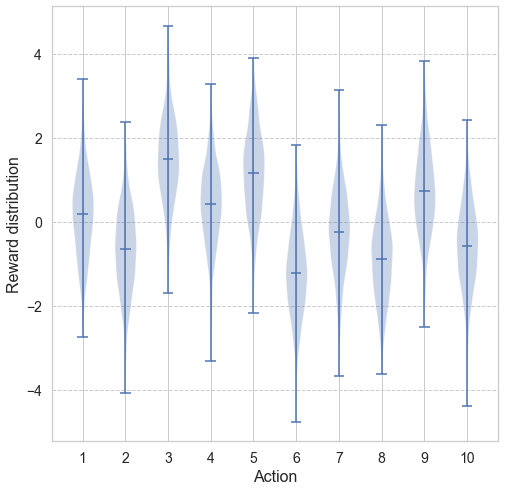

In [8]:
# setup 10 means for action rewards
np.random.seed(19801031)
means = [0.2,-0.7,1.5,0.5,1.2,-1.2,-0.2,-0.9,0.7,-0.5]

# generate data by sampling 1000 random rewards for each mean from the normal distribution 
rewards = [np.random.normal(mu,1,1000) for mu in means]

# visualize the samples
plt.figure(figsize=(8, 8))
plt.xlabel("Action")
plt.ylabel("Reward distribution")
plt.xticks([y+1 for y in range(len(rewards))], )
plt.grid(axis='y', linestyle='--', linewidth=1)
v = plt.violinplot(rewards, showmeans=True)

## Update rule
- The implementation uses an *incremental computation* of averages of obtained rewards 
- Given that the value of an action at time $t=n$ is defined as  
$$Q_n \doteq \frac{1}{n-1} \sum_{i=1}^{n-1} R_i$$
we can derive the the **update rule**


\begin{align*}
Q_{n+1} \doteq & \frac{1}{n} \sum_{i=1}^n R_i = \frac{1}{n} \left(\frac{(n-1)\cdot 1}{(n-1)}\sum_{i=1}^{n-1} R_i + R_n\right) \\
& = \frac{1}{n} \left((n-1)Q_n + R_n\right) = \frac{1}{n} \left(nQ_n - Q_n + R_n\right) \\
& = Q_n + \frac{1}{n} \left(R_n-Q_n\right)
\end{align*}

## General form

$$Q_{n+1} \doteq Q_n + \alpha \left(R_n-Q_n\right)$$

or in a text representation

$$New\_Estimate \gets Old\_Estimate + Step\_Size [Target - Old\_Estimate]$$

## Training a model

The action-value agent is trained to recognize the best strategy to pull the levers. Since the values of one experiment are not representative, we conduct a number of experiments and average out their results. As a result, the average gains of an agent after a number of actions can easily be visualized.

The experiment with the action-value agent uses the following parameters:
+ `eps` - exploration threshold of the $\epsilon$-greedy method
+ `trials` - the number of actions that an agent can execute in the environment
+ `runs` - the number of the experiment repetitions


- Note: the step size in the update rule $Q_n + \frac{1}{n} \left(R_n-Q_n\right)$ is *decreasing* as $n$ grows

Execution time: 15.112610578536987 seconds


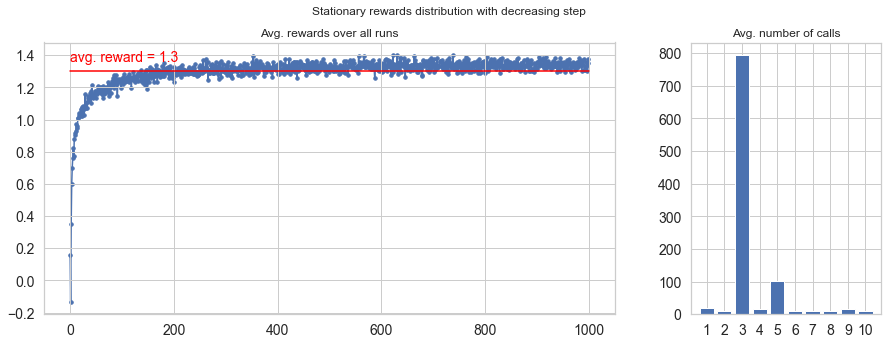

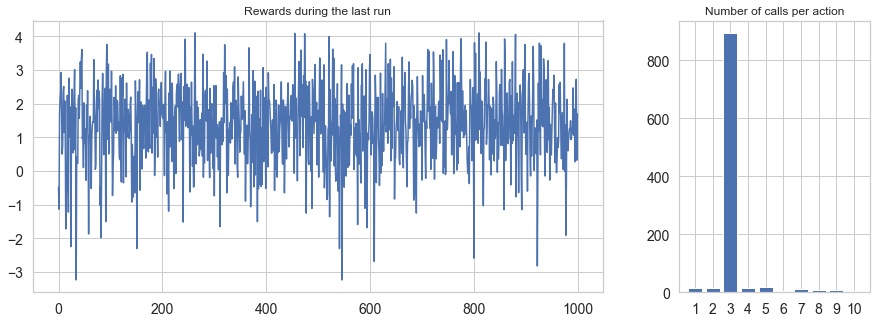

In [9]:
b = Bandit(Stationary(means), Decreasing())
b.run(trials=1000, runs=2000, eps=0.1)

The plots of the average results as well as of the results obtained in the last iteration show that the agent clearly identifies that the 3rd and 5th actions are the best ones (actual means are 1.5 and 1.2, resp.)

Execution time: 16.727341413497925 seconds


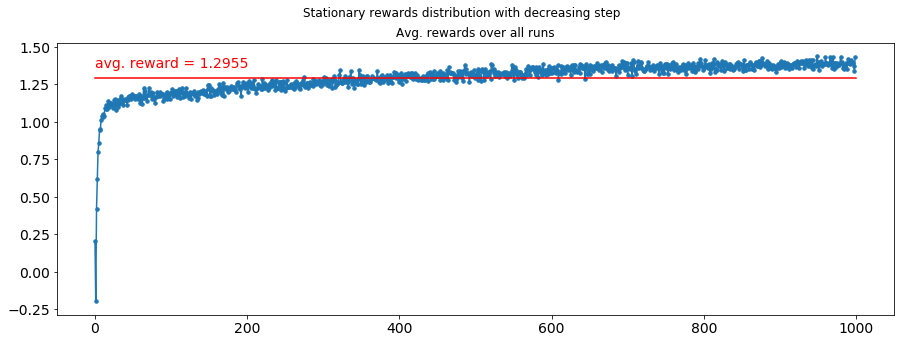

Execution time: 18.261755228042603 seconds


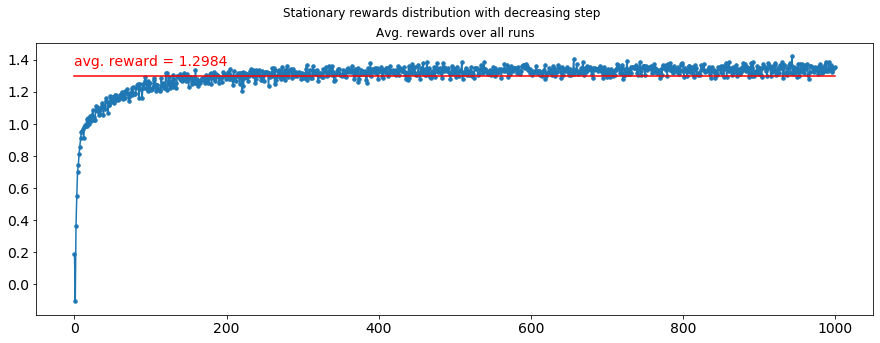

Execution time: 22.79110836982727 seconds


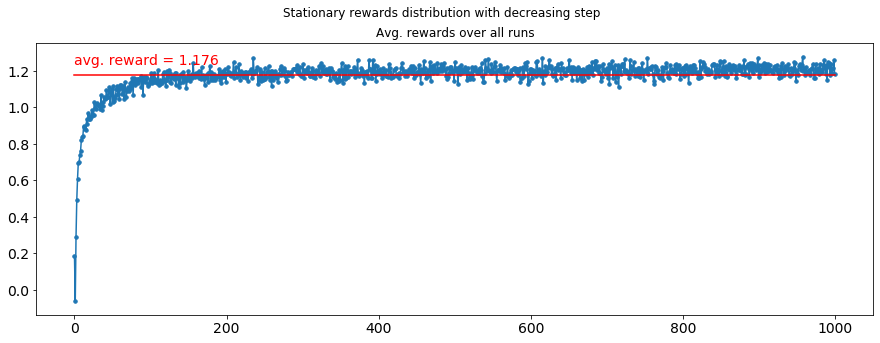

In [5]:
b = Bandit(Stationary(means), Decreasing())
# try different greedy strategies
trials=1000 
runs=2000
b.run(trials, runs, eps=0.01, show_last_run=False, show_avg_actions=False)
b.run(trials, runs, eps=0.1,  show_last_run=False, show_avg_actions=False)
b.run(trials, runs, eps=0.2,  show_last_run=False, show_avg_actions=False)

## Optimistic initial values

- Optimistic initial action values can be used to encourage exploration at the beginning of the search
    - In the previous experiments we used a small value of `0.001` as an initial value
    - Given that the rewards are sampled from a normal distribution with `0` mean and `1` standard deviation, an initial value of `5` is very optimistic
- This strategy finds a policy found at the beginning of the run keeps it unchanged till the end of the experiment
    

Execution time: 20.124207019805908 seconds


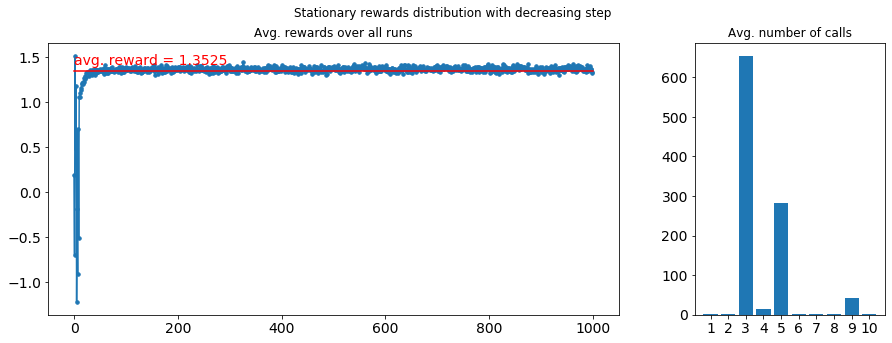

In [6]:
b = Bandit(Stationary(means), Decreasing(), init_value=5)
b.run(1000, 2000, 0, show_last_run=False)

## Nonstationary *k*-armed Bandit problem

- The problem considered above is also called **stationary**
    - underlying probability distribution for every lever remains the same (neither mean nor standard deviation) 
    - real-world problems there can be situations when distributions change over time - **nonstationary** problems

Execution time: 207.49157214164734 seconds


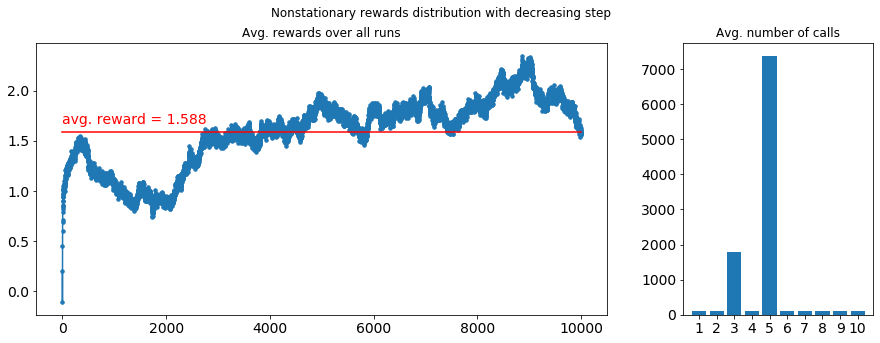

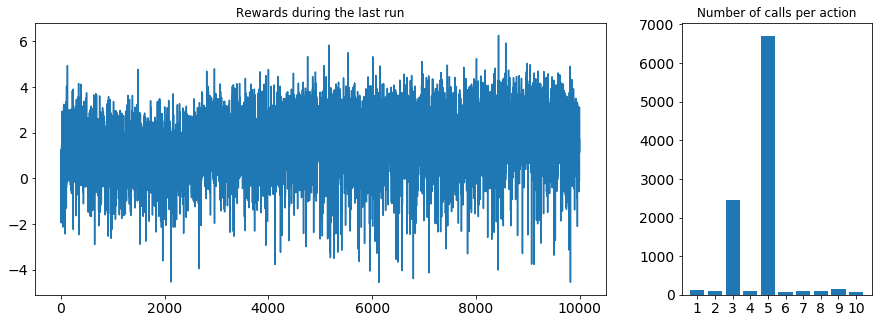

In [7]:
from rf.agent import Nonstationary, Constant

trials=10000
runs=2000
eps=0.1
rewards = Nonstationary(means, trials, mod_std=0.03)

b = Bandit(rewards, Decreasing())
b.run(trials, runs, eps)

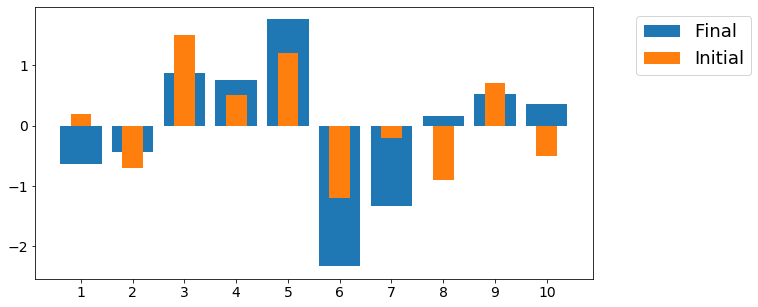

In [18]:
# Comparison of means of reward distributions

actions = range(1,len(rewards._cmeans)+1)
plt.figure(figsize=(10,5))
plt.xticks(actions)
plt.bar(actions, rewards._cmeans, zorder=-1, label="Final")
plt.bar(actions, rewards._means, width=0.4, zorder=1, label="Initial")
plt.legend(loc="upper right", bbox_to_anchor=(1.3,1))

## Track changes

- In such cases it might be reasonable to give more weight to the latest rewards than to long-past ones
    - Intuition: latter rewards might be obtained by pulling levers which wining probabilities already changed
    - Therefore, they can no longer be considered as informative

## Constant step

- One possibility to deal with nonstationary problems is to use the constant step size $\alpha \in (0,1]$
- If $\alpha$ is constant, the update rule can be reformulated as follows:

$$ Q_{n+1} \doteq Q_n + \alpha[R_n-Q_n] = Q_n - \alpha Q_n + \alpha R_n = (1-\alpha) Q_n + \alpha R_n = (1-\alpha) [(1-\alpha)Q_{n-1} + \alpha R_{n-1}] + \alpha R_n = $$

$$=(1-\alpha)^2 Q_{n-1} + (1-\alpha)\alpha R_{n-1} + \alpha R_n = (1-\alpha)^n Q_1 + (1-\alpha)^{n-1}\alpha R_1 + \dots + (1-\alpha)\alpha R_{n-1} + \alpha R_n=$$

$$=(1-\alpha)^n Q_1 + \sum_{i=1}^{n}(1-\alpha)^{n-i}\alpha R_i$$


- The latter corresponds to a weighted average of the initial estimate $Q_1$ and the past rewards $R_i$, since  
$$(1-\alpha)^n + \sum_{i=1}^{n}\alpha(1-\alpha)^{n-i} = 1$$

**Problem**: Prove the equality above using the formula for geometric progression.

Execution time: 204.85021924972534 seconds


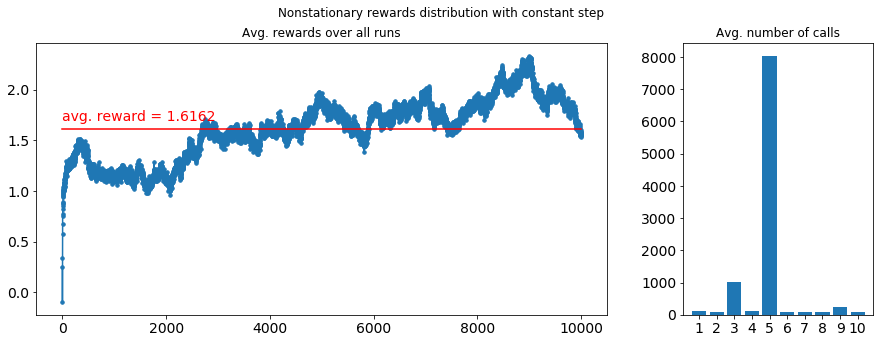

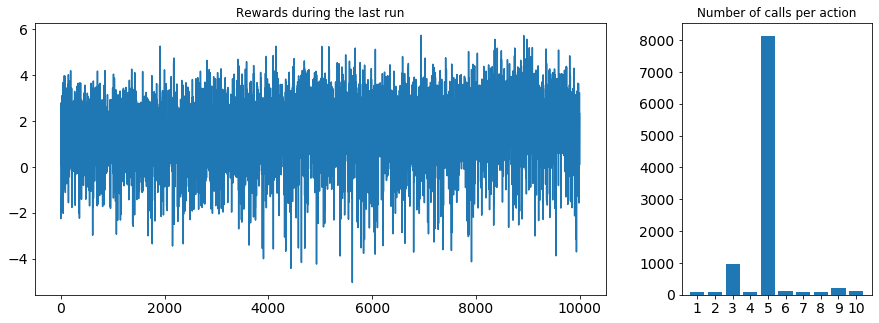

In [9]:
from rf.agent import Constant

b = Bandit(rewards, Constant(0.1))
b.run(trials, runs, eps)

## Unbiased constant step

- The problem with the constant step is that it introduces a significant bias towards rewards obtained at the beginning of each run
- This bias can be reduced by introducing dynamically changing step sizes
- One of the possibilities is
$$\beta_n = \frac{\alpha}{w_n} \text{ where } w_n = w_{n-1} + \alpha(1 - w_{n-1}) \text{ with } w_0=0$$

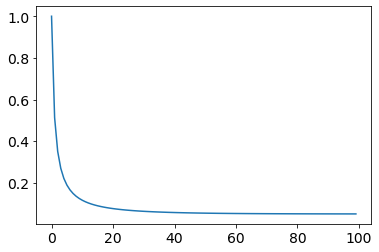

In [30]:
w = 0
a = 0.1
b = []
for i in range(100):
    w += a*(1-w)
    b.append(a/w)
plt.plot(b)

Execution time: 231.3177306652069 seconds


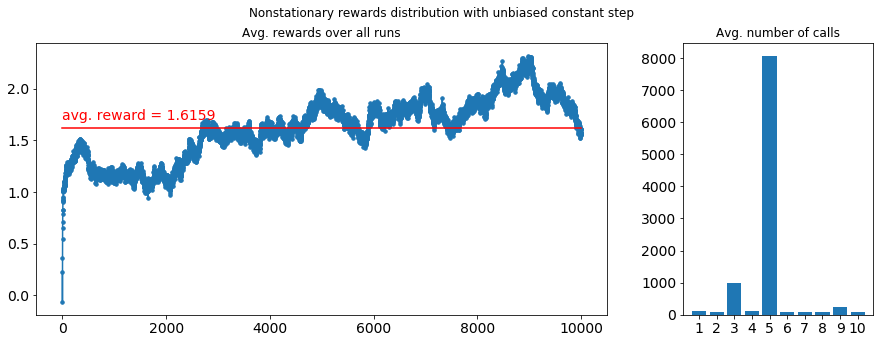

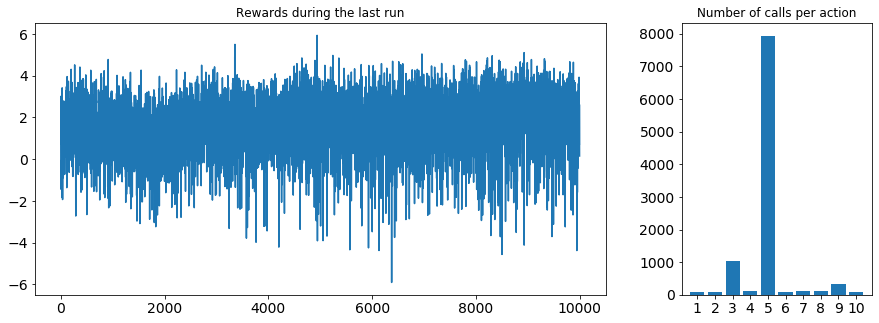

In [32]:
from rf.agent import UnbiasedConstant

b = Bandit(rewards, UnbiasedConstant(0.1))
b.run(trials, runs, eps)

## Parameter study

- Just as any ML algorithm, RL approaches considered so far depend on a number of parameters
    - $\epsilon$ to balance the exploration (identification/estimation) and exploitation (control)
    - $\alpha$ to determine the impact of new observations on the action selection policy
- Finding optimal parametrization is hard
- In some cases, additional knowledge might help to determine the optimal values - Bayesian methods
  - Assume a known prior distribution of action values and then update them, e.g., games played by best human players can be used to determine the prior probability
  - Given some look-ahead horizon we can estimate future rewards
  - In some situations specific methods, like Gittins index, allow for tractable estimation of future rewards
  - Computation of optimal balance for Bayesian formulation is possible using dynamic programming (Bellman)

## Upper confidence bound (UCB)

- $\epsilon$-greedy allows for the selection of non-greedy actions
    - but provides no preference - uniform distribution
- UCB selects non-greedy actions according to their likelihood for being the optimal ones
$$A\_t \doteq \underset{a \in \mathcal{A}}{\arg\max}\left[Q_t(a)+c\sqrt{\frac{\ln t}{N_t(a)}}\;\right]$$
where $N_t(a) = \sum_{i=1}^{t-1} \mathbf{1}_{A_i=a}$ - the number of times $a$ was selected before the time $t$
  - if $a$ was never chosen before, then $N_t(a)=m$, where $m$ is some very small number in the interval $[0,1]$
  - the term $\sqrt{\frac{\ln t}{N_t(a)}}$ measures the uncertainty in the estimate of the value of $a$
    - the more $a$ is selected the less uncertainty is there about its value
    - $\ln$ allows us to keep the nominator increasing, but limits its grows rate
  - $c$ determines the confidence level for the measure
  
- UCB performs well for bandits, but is hard to extend to other problems

### Gradient Algorithms

- Assume we would like to learn a numerical preference for an action $H_t(a)$ instead of its value
- The probability $\pi_t(a)$ for an action to be selected at a time $t$ can be determined according to the soft-max distribution (aka Gibbs or Boltzmann distribution)
$$P(A_t=a) \doteq \frac{e^{H_t(a)}}{\sum_{b=1}^k e^{H_t(b)}}\doteq \pi_t(a)$$
- At $t=1$, $\forall a\; H_1(a)=0$, all actions are equally possible
- For all other values of $t$, after the action $A_t$ is selected, the preferences are updates as follows:
$$H_{t+1}(a) \doteq H_t(a) + \alpha\frac{\partial\mathbb{E}[R_t]}{\partial H_t(a)}$$
where 
  - expected reward $\mathbb{E}[R_t] = \sum_a \pi_t(a)q_*(a)$ is the measure of the performance
  - $\alpha$ is a learning rate parameter, 
  - $R_t$ is the reward obtained at the time $t$
- The latter can be shown to be equivalent to
$$H_{t+1}(a) \doteq H_t(a) + \alpha(R_t-\overline{R}_t)(\mathbf{1}_{A_i=a} - \pi(a))$$
where 
  - $\overline{R}_t$ is a baseline - an average of the rewards obtained before $t$ (computed incrementally as above)
  - $(R_t-\overline{R}_t)(\mathbf{1}_{A_i=a} - \pi(a))$ is the expected performance of an action in comparison to the baseline
    - if the reward is higher than the baseline, the probability of taking $a$ in the future increases

# RL Algorithms

- Model-free vs. Model-based
  - the main difference is in whether an agent has a model of the environment (given or learned)
  - the model is a function that predicts state transitions and rewards
  - model allows an agent to execute planning (multi-step look ahead) assign possible choices and their consequences
  - *a model is quite hard to get!* - create manually or learn from the available data (bias)
  - model-free algorithms are easier to implement and tune
  
- Different algorithms aim to learn different things
  - policies: stochastic or deterministic,
  - Q-function (action-value functions above),
<!--   - value functions or models -->

## Value function

- Measure the goodness of a state, i.e. how good is this state for future rewards
$$G_t = R_{t+1} + \gamma R_{t+2} + \dots = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1}$$
- The factor $\gamma \in [0,1]$ penalizes the future rewards since
    - We cannot benefit from them now and we are not certain about them anyhow, the further in the future the more
    - The discounting is good from algorithmic perspective: infinite loops in the transition graph, convergence of algorithms, etc.

## On-policy approach: SARSA

- The method updates the Q-value by following a sequence $\dots, S_t, A_t, R_{t+1}, S_{t+1}, A_{t+1}, \dots$ 
- In the initialization stage:
    - Set $t=0$ and create $S_0$
    - Select action $A_0 = \arg\max_{a \in \mathcal{A}} Q(S_0, a)$, (e.g., using $\epsilon$-greedy)
- At time $t$: 
    - Apply action $A_t$, get the reward $R_{t+1}$ and the next state $S_{t+1}$
    - Select an action $A_{t+1} = \arg\max_{a \in \mathcal{A}} Q(S_{t+1}, a)$
    - Update the Q-value function: $ Q(S_t, A_t) = Q(S_t, A_t) + \alpha (R_{t+1} + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t))$
    - Set $t = t+1$ and repeat  
- *On-policy*: SARSA selects the next action using the current policy $\gamma Q(S_{t+1}, A_{t+1})$
- *Time-difference learning*: $\gamma Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t)$
    - Initialization issues are quite often resolved using *imitation learning* or *bootstrapping* with search methods

## Off-policy approach: Q-learning

- In the initialization stage:
    - Set $t=0$ and create $S_0$
- At time $t$: 
    - Select the action $A_t = \arg\max_{a \in \mathcal{A}} Q(S_t, a)$ 
    - Apply $A_t$ and get reward $R_{t+1}$ and the next state $S_{t+1}$
    - Update the Q-value function: $Q(S_t, A_t) = Q(S_t, A_t) + \alpha (R_{t+1} + \gamma \max_{a \in \mathcal{A}} Q(S_{t+1}, a) - Q(S_t, A_t))$ 
    - Set $t = t+1$ and repeat
- *Off-policy*: while selecting the next action, Q-learning does not follow the current policy $\gamma \max_{a \in \mathcal{A}} Q(S_{t+1}, a)$
- Q-learning is only interested in estimating the $Q^*$, but not which action leads to it

## Deep Q-Network (DQN)

- [Deep Q-Networks](https://www.cs.toronto.edu/~vmnih/docs/dqn.pdf) (DQN) is a classic example of a learning algorithm that approximates the Q-function by a neural network
    - $(+)$ Applicable to very complex states, e.g., images
    - $(+)$ Can handle large number of actions
    - $(-)$ Evaluation of an NN might take much time
- DQN approach is characterized by
    - Common replay memory $D_t = \{e_1, \dots, e_t\}$, where each episode $e_i = (S_i, A_i, R_i, S_{i+1})$
    - Updates the Q-function stored in the network with a period $C$ - Double DQN
        - Create two networks: current $Q$ and target $\hat{Q}$
        - Select actions using $\hat{Q}$ but perform all weight updates on $Q$
        - Swap $\hat{Q} = Q$ every $C$ steps

## DQN Algorithm

- Original algorithm is oriented on the image input
    - Preprocessing of images: resolution reduction, color normalization, etc.
    - Uses CNN with an $84 \times 84 \times 4$ image with 3 convolutional followed by 2 decision layers
- Easy adaptation to other architectures and preprocessing methods

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/04_RL/images/ddqn.png" width="60%"/>
</center>
<p style="text-align:right" class="cite">Mnih, et al. <a href="https://www.cs.swarthmore.edu/~meeden/cs63/s15/nature15b.pdf">Human-level control through deep reinforcement learning.</a> Nature 518.7540 (2015): 529</p>

## Policy optimization

- Learn possibly optimal policy $\pi_\theta(s)$ directly by optimizing parameters $\theta$ of the policy function using gradient descent on the objective $J(\pi_\theta(s))$
- Optimization is usually done on-policy - greedy evaluation of the policy function
- Updates of the policy are done by learning an approximation of the on-policy value function, i.e., an assessment of how good a given action or a given state is for the agent
- *Main algorithms*
  - Actor-Critic (A2C) or [Asynchronous Actor Critic](https://arxiv.org/abs/1602.01783) (A3C) - gradient descent to directly maximize the performance
  - [Proximal Policy Optimization](https://arxiv.org/abs/1707.06347) (PPO) - indirect optimization of the performance by estimating a change of the objective $J(\pi_\theta(s))$ after update

## Get the best of the two worlds!
  - [Deep Deterministic Policy Gradient](https://arxiv.org/abs/1509.02971) (DDPG) - learn both a deterministic policy and a Q-function and use each of them to improve the other
  - [Soft Actor-Critic](https://arxiv.org/abs/1801.01290) (SAC), stabilize learning using a variety of methods including stochastic policies and entropy regularization